# 05 — Size scaling

**Sweep 2.** Vary `n in {4, 6, 8, 10, 12, 14, 16}` by drawing 20 random
size-n subsets of the canonical 16-equity universe (single canonical
subset for n=16). For each subset we recompute the QUBO from the
sub-(μ, Σ) and run every solver, then report median + IQR across
subsets. The `n=16` endpoint by construction matches the run in
notebooks 02/03/04/06.

`K = round(0.25 * n)` so at n=16 we recover K=4 = `DEFAULTS["K_AT_16"]`.

Honest expectation at these sizes: classical methods are strictly better
— faster, more reliable, no barren plateaus. QAOA matches optimality
but doesn't outperform. The methodology is the point.

> **Runtime:** ~45–60 min on Colab CPU from scratch. **Crash-safe:** the
> sweep writes after each subset, so a disconnect costs at most one subset
> and a re-run resumes from where it left off.

In [1]:
# === Bootstrap (Colab + local) ===
import os, urllib.request as _u
exec((open('../scripts/bootstrap.py') if os.path.exists('../scripts/bootstrap.py') else _u.urlopen('https://raw.githubusercontent.com/egil10/fys5419/main/project2/code/scripts/bootstrap.py')).read())

# === Project imports ===
import json
import numpy as np
import pandas as pd

from scripts.colab     import out_dir
from scripts.data      import load_universe
from scripts.portfolio import PortfolioProblem, DEFAULTS
from scripts.classical import brute_force, greedy_top_k, simulated_annealing, markowitz_round
from scripts.qaoa      import solve, make_hamiltonians
from scripts.metrics   import prob_optimal, scaled_ratio, gap

RESULTS = out_dir('results')
print(f'Results will be saved to: {RESULTS}')

> /usr/bin/python3 -m pip install -q numpy pandas scipy matplotlib yfinance pyarrow
[colab.setup] env=Colab
[colab.setup] cwd  = /content/fys5419/project2/code/notebooks
[colab.setup] path = /content/fys5419/project2/code  (added to sys.path)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5419/project2/code/results


In [ ]:
# === Scaling protocol ===
# Use the canonical 16-asset universe and SUB-SAMPLE for each n.
# For each n in N_VALUES, draw M_for(n) random size-n subsets and run
# every solver on the (mu, Sigma) restricted to that subset. Report
# median + IQR across subsets.
#
# K is the ratio rule (K = round(K_FRAC * n)). K_AT_16 = round(0.25*16) = 4,
# so the n=16 endpoint matches notebooks 02/03/04/06 exactly.
#
# M_for(n) is tiered: small-n is cheap so we draw lots; large-n is slow
# (QAOA cost ~ 2^n * p * n_restarts * cobyla_iters) so we draw fewer.
# n=14 was bumped from 4 -> 10 so the IQR at the largest "spread" point
# is genuinely informative (4 points is degenerate). n=16 is and remains
# the single canonical universe — there are no size-16 *subsets* to draw
# from a size-16 universe, so the IQR band is suppressed in the plotting.

N_VALUES   = [4, 6, 8, 10, 12, 14, 16]
P          = 3                  # QAOA depth
N_RESTARTS = 10                 # multi-start seeds for QAOA + SA
LAM        = DEFAULTS['lam']
AP         = DEFAULTS['A']
K_FRAC     = DEFAULTS['K_FRAC']
SEED       = 42

def M_for(n: int) -> int:
    """Tiered subset count — fewer draws as QAOA cost explodes."""
    if n == 16: return 1   # the single canonical instance (universe == universe)
    if n >= 14: return 10  # bumped from 4 -> 10; gives a real IQR at the tail
    if n >= 12: return 8   # ~8 min at n=12
    return 20              # cheap regime, lots of samples for tight IQR

# Compatibility shim so the cache-inspect cell + sweep cell can reference
# a per-n target (used as `target` for the resume logic).
M_SUBSETS = max(M_for(n) for n in N_VALUES)

universe = load_universe()
print(f'universe: n={universe.n}  tickers={universe.tickers}')
print(f'\nTiered subset counts:')
for n in N_VALUES:
    print(f'  n={n:2d}  M_for(n)={M_for(n)}')
print(f'\nTotal subsets to compute: {sum(M_for(n) for n in N_VALUES)}')

In [3]:
# === Cache inspection (read-only, ~0s) ===
# Run BEFORE the sweep cell to see what's already on disk.
cache = RESULTS / 'size_scaling.json'

if not cache.exists():
    print(f'No cache yet at {cache}  -> sweep will compute everything from scratch.')
else:
    import json
    _rows = json.loads(cache.read_text())
    print(f'Cache: {cache}  ({len(_rows)} records)')
    by_n = {}
    for r in _rows:
        by_n.setdefault(r['n'], set()).add(r['subset_id'])
    print(f"  {'n':>3}  {'done':>5}  {'target':>6}  status")
    for n in N_VALUES:
        target = M_for(n)
        d = len(by_n.get(n, set()))
        status = 'COMPLETE' if d >= target else f'partial ({target - d} remaining)'
        print(f'  {n:>3}  {d:>5}  {target:>6}  {status}')
    total_target = sum(M_for(n) for n in N_VALUES)
    total_done   = sum(len(s) for s in by_n.values())
    print(f'\nOverall: {total_done}/{total_target} subsets done.  '
          f"Sweep will {'load and skip' if total_done >= total_target else 'resume from where it left off'}.")

No cache yet at /content/drive/MyDrive/GITHUB-COLAB/fys5419/project2/code/results/size_scaling.json  -> sweep will compute everything from scratch.


In [4]:
cache = RESULTS / 'size_scaling.json'

def _solve_subset(sub, K):
    """Run every solver on a sub-universe and return one record per solver.

    Reports two QAOA-vs-classical metrics for each solver:

      ratio    : scaled approximation ratio (E_worst - cost)/(E_worst - E_opt)
                 in [0, 1]. r=1 at the true optimum, r=0 at the worst basis
                 state. Stable under mixed-sign cost — use this instead of
                 cost / E_opt, which explodes when E_opt is near zero (the
                 common case here once the penalty vanishes at feasibility).
      gap_rel  : (cost - E_opt) / |E_opt|. 0 = optimal. Easier to read for
                 small perturbations but unbounded above.
    """
    pf = PortfolioProblem(sub.mu, sub.Sigma, lam=LAM, A=AP, K=K,
                          tickers=sub.tickers)
    bf = brute_force(pf)
    gr = greedy_top_k(pf, score='sharpe')
    mr = markowitz_round(pf)

    sa_runs = [simulated_annealing(pf, n_sweeps=1000*pf.n, seed=s)
               for s in range(N_RESTARTS)]
    sa_costs = np.array([sr.cost for sr in sa_runs])
    sa_best  = float(sa_costs.min())
    sa_time  = float(np.median([sr.runtime for sr in sa_runs]))

    qres = solve(pf, p=P, n_restarts=N_RESTARTS, seed=SEED)

    # Spectrum endpoints in COST units. make_hamiltonians returns HC + offset
    # so HC.min() matches bf.cost; from_portfolio drops the offset and would
    # shift everything by AK^2 (a real bug if you mix them up).
    _, _, _, _, _, HC = make_hamiltonians(pf)
    e_opt   = float(HC.min())
    e_worst = float(HC.max())

    def row(name, cost, runtime, extra=None):
        r = {'solver': name,
             'cost':     float(cost),
             'runtime_s': float(runtime),
             'ratio':    scaled_ratio(cost, e_opt, e_worst),
             'gap_rel':  gap(cost, e_opt),
             'e_opt':    e_opt,
             'e_worst':  e_worst}
        if extra: r.update(extra)
        return r

    return [
        row('brute_force',     bf.cost,                  bf.runtime),
        row('greedy_sharpe',   gr.cost,                  gr.runtime),
        row('markowitz_round', mr.cost,                  mr.runtime),
        row('sa_best',         sa_best,                  sa_time),
        row(f'qaoa_p{P}',      float(qres['energy']),    qres['runtime'],
            extra={'p_optimal': prob_optimal(qres['probs'], bf.x)}),
    ]


def _to_python(o):
    if isinstance(o, dict):           return {k: _to_python(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):  return [_to_python(v) for v in o]
    if isinstance(o, np.integer):     return int(o)
    if isinstance(o, np.floating):    return float(o)
    return o


def _save(rows):
    """Atomic write — temp file then rename, so a kill mid-write can't corrupt."""
    tmp = cache.with_suffix('.json.tmp')
    tmp.write_text(json.dumps(_to_python(rows), indent=2))
    tmp.replace(cache)


def _subsets_for(n, M):
    """Deterministic random subsets of size n.

    Per-n RNG so the first M draws are bit-exact regardless of how many
    other n's have been drawn — makes resume safe across reruns even if
    M_for changes or N_VALUES is reordered.
    """
    if n == universe.n:
        return [tuple(range(universe.n))]
    rng_n = np.random.default_rng(SEED * 100003 + n)
    return [tuple(sorted(int(i) for i in
                         rng_n.choice(universe.n, size=n, replace=False)))
            for _ in range(M)]


# === Crash-safe incremental sweep ===
# Writes to disk after EVERY subset, so a disconnect costs at most one
# subset (~1-5 min), not the whole run. Re-running picks up where it left off.
#
# Cache format note: rows must carry the 'ratio' field as the SCALED ratio.
# Older caches that stored cost / bf.cost (mixed-sign blow-ups, ratios of
# +7000 or -2800) are not compatible — delete `size_scaling.json` before
# rerunning if you see ratios outside roughly [-0.5, 1.5].

if cache.exists():
    rows = json.loads(cache.read_text())
    # Sanity-check old cache: scaled_ratio lives in [0, 1] for any sane run.
    _ratios = [r.get('ratio', 1.0) for r in rows]
    if _ratios and (min(_ratios) < -0.5 or max(_ratios) > 1.5):
        raise RuntimeError(
            f'{cache.name} contains ratios outside [-0.5, 1.5] '
            f'(min={min(_ratios):.2f}, max={max(_ratios):.2f}) — this is the '
            f'legacy cost/E_opt ratio format. Delete the file and rerun this '
            f'cell to regenerate with the scaled ratio.'
        )
    print(f'resuming from {cache.name}  ({len(rows)} records already saved)')
else:
    rows = []

done = {(rec['n'], rec['subset_id']) for rec in rows}

for n in N_VALUES:
    K = max(1, round(K_FRAC * n))
    subset_idxs = _subsets_for(n, M_for(n))

    for subset_id, idx in enumerate(subset_idxs):
        if (n, subset_id) in done:
            continue
        sub = universe.subset(idx)
        for rec in _solve_subset(sub, K):
            rec.update({'n': int(n), 'K': int(K),
                        'subset_id': int(subset_id),
                        'subset_idx': list(idx)})
            rows.append(rec)
        _save(rows)
        print(f'  n={n:2d}  K={K}  subset {subset_id+1}/{len(subset_idxs)}  '
              f'(total {len(rows)} records saved)')

print(f'done -> {cache.name}  ({len(rows)} records)')
df = pd.DataFrame(rows)
df.groupby(['n', 'solver'])['ratio'].agg(['median', 'mean', 'std', 'count'])

  n= 4  K=1  subset 1/20  (total 5 records saved)
  n= 4  K=1  subset 2/20  (total 10 records saved)
  n= 4  K=1  subset 3/20  (total 15 records saved)
  n= 4  K=1  subset 4/20  (total 20 records saved)
  n= 4  K=1  subset 5/20  (total 25 records saved)
  n= 4  K=1  subset 6/20  (total 30 records saved)
  n= 4  K=1  subset 7/20  (total 35 records saved)
  n= 4  K=1  subset 8/20  (total 40 records saved)
  n= 4  K=1  subset 9/20  (total 45 records saved)
  n= 4  K=1  subset 10/20  (total 50 records saved)
  n= 4  K=1  subset 11/20  (total 55 records saved)
  n= 4  K=1  subset 12/20  (total 60 records saved)
  n= 4  K=1  subset 13/20  (total 65 records saved)
  n= 4  K=1  subset 14/20  (total 70 records saved)
  n= 4  K=1  subset 15/20  (total 75 records saved)
  n= 4  K=1  subset 16/20  (total 80 records saved)
  n= 4  K=1  subset 17/20  (total 85 records saved)
  n= 4  K=1  subset 18/20  (total 90 records saved)
  n= 4  K=1  subset 19/20  (total 95 records saved)
  n= 4  K=1  subset 20

median      mean           std  count
n  solver                                                  
4  brute_force      1.000000  1.000000  1.139065e-16     20
   greedy_sharpe    1.000000  0.999950  2.215383e-04     20
   markowitz_round  1.000000  0.999994  2.547228e-05     20
   qaoa_p3          0.986587  0.986402  1.620954e-03     20
   sa_best          1.000000  1.000000  1.139065e-16     20
6  brute_force      1.000000  1.000000  1.139065e-16     20
   greedy_sharpe    1.000000  0.999789  5.182650e-04     20
   markowitz_round  1.000000  0.999922  3.408080e-04     20
   qaoa_p3          0.982931  0.983211  8.262216e-04     20
   sa_best          1.000000  1.000000  1.139065e-16     20
8  brute_force      1.000000  1.000000  1.347760e-16     20
   greedy_sharpe    1.000000  0.999997  7.954727e-06     20
   markowitz_round  1.000000  0.999998  7.494700e-06     20
   qaoa_p3          0.992454  0.991997  9.874001e-04     20
   sa_best          1.000000  1.000000  1.347760e-16     20
10 brute_force      1.000000  1.000000  1.139065e-16     20
   greedy_sharpe    0.999989  0.999994  5.639539e-06     20
   markowitz_round  1.000000  0.999995  8.010182e-06     20
   qaoa_p3          0.987742  0.987721  2.370640e-04     20
   sa_best          1.000000  1.000000  1.139065e-16     20
12 brute_force      1.000000  1.000000  1.512979e-16      8
   greedy_sharpe    1.000000  0.999998  2.822565e-06      8
   markowitz_round  1.000000  0.999999  1.891488e-06      8
   qaoa_p3          0.981871  0.974565  1.614530e-02      8
   sa_best          1.000000  1.000000  1.512979e-16      8
14 brute_force      1.000000  1.000000  0.000000e+00      4
   greedy_sharpe    0.999989  0.999987  1.194701e-05      4
   markowitz_round  0.999994  0.999994  5.629502e-06      4
   qaoa_p3          0.982368  0.982638  1.151928e-03      4
   sa_best          1.000000  1.000000  0.000000e+00      4
16 brute_force      1.000000  1.000000           NaN      1
   greedy_sharpe    1.000000  1.000000           NaN      1
   markowitz_round  1.000000  1.000000           NaN      1
   qaoa_p3          0.944622  0.944622           NaN      1
   sa_best          1.000000  1.000000           NaN      1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


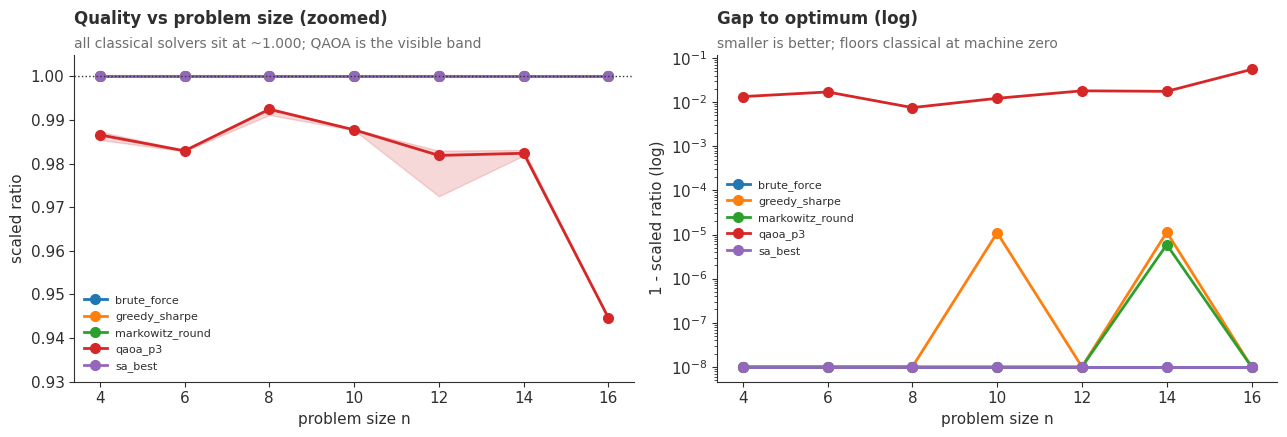

In [5]:
# === Zoomed + log-gap view (cache-only, ~1s) ===
# Reads the size_scaling.json that the sweep above just wrote and produces
# a second figure that makes the QAOA-vs-classical gap visible. Safe to
# re-run any time — touches nothing else.
import matplotlib.pyplot as plt
from scripts.plotting import apply_style, PALETTE, title, fig_path
apply_style()

_scale = pd.DataFrame(json.loads((RESULTS / 'size_scaling.json').read_text()))
_agg = (_scale
        .groupby(['n', 'solver'])
        .agg(median_ratio=('ratio', 'median'),
             q25_ratio   =('ratio', lambda s: s.quantile(0.25)),
             q75_ratio   =('ratio', lambda s: s.quantile(0.75)))
        .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: zoomed to where the action is.
for solver, sub in _agg.groupby('solver'):
    sub = sub.sort_values('n')
    line, = axes[0].plot(sub.n, sub.median_ratio, 'o-', lw=2, ms=7, label=solver)
    axes[0].fill_between(sub.n, sub.q25_ratio, sub.q75_ratio,
                         color=line.get_color(), alpha=0.18)
axes[0].axhline(1.0, color=PALETTE['charcoal'], ls=':', lw=1)
axes[0].set_xlabel('problem size n')
axes[0].set_ylabel('scaled ratio')
axes[0].set_ylim(0.93, 1.005)
title(axes[0], 'Quality vs problem size (zoomed)',
      'all classical solvers sit at ~1.000; QAOA is the visible band')
axes[0].legend(fontsize=8); axes[0].grid(False)

# Right: 1 - ratio on a log axis. Floors at 1e-8 so brute/SA still plot.
_agg['gap_from_opt'] = (1.0 - _agg['median_ratio']).clip(lower=1e-8)
for solver, sub in _agg.groupby('solver'):
    sub = sub.sort_values('n')
    axes[1].semilogy(sub.n, sub.gap_from_opt, 'o-', lw=2, ms=7, label=solver)
axes[1].set_xlabel('problem size n')
axes[1].set_ylabel('1 - scaled ratio (log)')
title(axes[1], 'Gap to optimum (log)',
      'smaller is better; floors classical at machine zero')
axes[1].legend(fontsize=8); axes[1].grid(False)

plt.tight_layout()
fig.savefig(fig_path('compare', 'scaling_zoom'), bbox_inches='tight')
plt.show()
